# Testing PlotKit Explanations API

This notebook demonstrates and tests the `explainer()` function from PlotKit.

## Features Tested
- Basic explanation generation
- Multi-provider support (OpenAI, Groq, Anthropic, etc.)
- Model selection with `selected_models`
- Interactive and non-interactive modes
- Error handling for unsupported models

## Setup: Import Libraries

In [1]:
import os
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from plotsense.explanations.explanations import explainer

# Load environment variables from .env file
load_dotenv()

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


## Step 1: Create a Test Plot

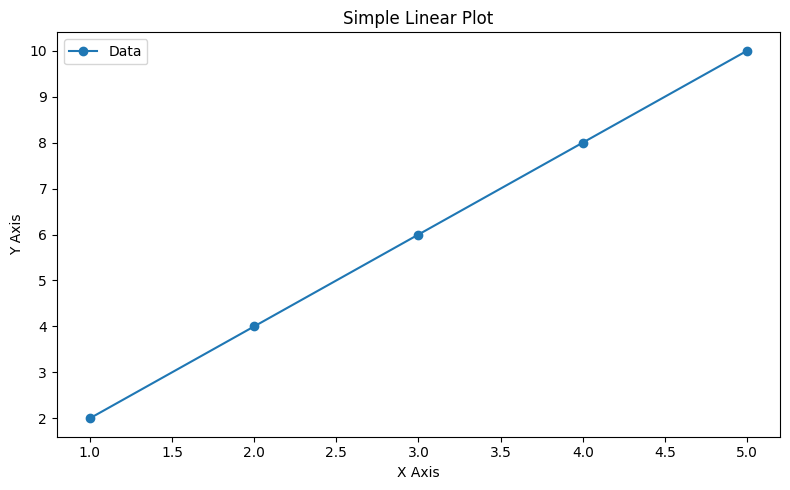

✅ Test plot created


In [2]:
# Create a simple line plot
fig, ax = plt.subplots(figsize=(8, 5))
x = [1, 2, 3, 4, 5]
y = [2, 4, 6, 8, 10]
ax.plot(x, y, marker='o', label='Data')
ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_title('Simple Linear Plot')
ax.legend()
plt.tight_layout()
plt.show()

print("✅ Test plot created")

## Step 2: Setup API Keys

In [3]:
# Option 1: Load from environment variables
api_keys = {}

if os.getenv("OPENAI_API_KEY"):
    api_keys["openai"] = "" # os.getenv("OPENAI_API_KEY")

if os.getenv("GROQ_API_KEY"):
    api_keys["groq"] = os.getenv("GROQ_API_KEY")

if os.getenv("ANTHROPIC_API_KEY"):
    api_keys["anthropic"] = os.getenv("ANTHROPIC_API_KEY")

print(f"Available API keys: {list(api_keys.keys())}")

Available API keys: ['openai', 'groq']


## Step 3: Test 1 - Basic Explanation

In [4]:
try:
    result = explainer(
        fig,
        prompt="Explain this plot in one sentence.",
        api_keys=api_keys,
        selected_models=[("openai", "gpt-4o-mini")],
        interactive=True, # len(api_keys) == 0,
        timeout=30
    )
    print("✅ Explanation generated:")
    print(f"\n{result}")
except ValueError as e:
    print(f"❌ Error: {e}")

⚙️  OPENAI API key not found.
🔗  Get it at 👉 https://platform.openai.com/api-keys 👈


Enter OPENAI API key:  ········


✅ OPENAI_CHAT API key validated successfully.
✅ OPENAI_RESPONSE API key validated successfully.
✅ Explanation generated:

# Data Visualization Analysis

## 1. Overview
The provided plot is a simple linear graph illustrating a perfect positive correlation between two variables, A and B, where an increase in A corresponds to a proportional increase in B.

## 2. Key Features
- **Title:** Simple Linear Plot
- **Axes:**
  - **X Axis:** Ranges from 1 to 5, representing variable A.
  - **Y Axis:** Ranges from 2 to 10, representing variable B.
- **Data Points:** The plot features five data points: (1, 2), (2, 4), (3, 6), (4, 8), and (5, 10), each marked with a blue circle.
- **Linearity:** Data points are connected by a straight line, confirming a linear relationship.
- **Legend:** The legend identifies the series as "Data," representing the observed pairs of (A, B).

## 3. Insights and Patterns
- **Positive Correlation:** The linear trend demonstrates that as A increases from 1 to 5, B increa

## Step 4: Test 2 - With OpenAI

In [ ]:
try:
    result = explainer(
        fig,
        prompt="Analyze this plot. What are the key characteristics?",
        api_keys=api_keys,
        selected_models=[("openai", "gpt-4o-mini")],
        interactive=len(api_keys) == 0,
        timeout=30
    )
    print("✅ OpenAI explanation generated:")
    print(f"\n{result}")
except ValueError as e:
    print(f"❌ Error: {e}")

## Step 5: Test 3 - With Groq

In [6]:
try:
    result = explainer(
        fig,
        prompt="Describe this plot briefly.",
        api_keys=api_keys,
        selected_models=[("groq", "llama-3.1-8b-instant")],
        interactive=True, #len(api_keys) == 0,
        timeout=30
    )
    print("✅ Groq explanation generated:")
    print(f"\n{result}")
except ValueError as e:
    print(f"❌ Error: {e}")

✅ Groq explanation generated:

# Refined Explanation of the Plot

## Overview
The plot depicts a perfect linear correlation between two variables, with the X-axis representing values from 1 to 5 and the Y-axis ranging from 2 to 10. The data points are connected by a straight line, indicating a direct and proportional relationship between the variables.

## Key Features
- **Axes**:
  - **X Axis**: Values range from 1 to 5.
  - **Y Axis**: Values range from 2 to 10.
  
- **Data Points**: 
  - Five distinct data points represented by blue circles at the coordinates: 
    - (1, 2)
    - (2, 4)
    - (3, 6)
    - (4, 8)
    - (5, 10)
  - The even spacing of the points reinforces the consistency and reliability of the linear relationship.

- **Trend Line**: 
  - A straight line connecting the data points visually indicates a strong upward trend, reflecting the positive correlation.

- **Legend**: 
  - The legend labels the data series as "Data," enhancing clarity.

## Insights and Patterns
-

## Step 6: Test 4 - Error Handling

In [ ]:
try:
    result = explainer(
        fig,
        prompt="Test",
        api_keys=api_keys,
        selected_models=[("openai", "gpt-5-turbo")],
        interactive=False
    )
except ValueError as e:
    print("✅ Error handling works!")
    print(f"\n{e}")

## Step 7: Available Models

In [ ]:
from plotsense.core.registry_loader import get_registry_loader

registry = get_registry_loader()

print("📋 AVAILABLE MODELS:\n")

print("OpenAI (Chat):")
for model in registry.get_provider_models("openai", "chat"):
    print(f"   - {model}")

print("\nGroq:")
for model in registry.get_provider_models("groq", "default"):
    print(f"   - {model}")

print("\nAnthropic:")
for model in registry.get_provider_models("anthropic", "default"):
    print(f"   - {model}")